# 1. Import le dataset

In [1]:
data_dpe <- read.table("/kaggle/input/datasets/vitnguynchong/data-analyse-dpe/data_dpe.txt",header = TRUE)
head(data_dpe)

,type_logement,annee_construction,surface_habitable,type_energie_chauffage,conso_energie,classe_conso_energie,emission_ges
,<int>,<int>,<int>,<int>,<dbl>,<chr>,<dbl>
1,1,1988,25,2,300.44,C,13.23
2,1,1996,64,1,148.17,D,34.67
3,1,1970,46,2,257.00,C,12.00
4,2,1958,74,1,317.03,F,74.18
5,1,2013,38,1,53.42,C,12.50
6,2,2006,65,2,176.09,B,6.09


Les variables sélectionnées pour cette étude sont les suivantes :

- **type_logement** : type du logement (1 = appartement, 2 = maison) — variable qualitative.
- **annee_construction** : année de construction du logement — variable quantitative.
- **surface_habitable** : surface habitable en mètres carrés — variable quantitative.
- **type_energie_chauffage** : type d’énergie utilisée pour le chauffage (1 = gaz, 2 = électricité, 3 = autre) — variable qualitative.
- **conso_energie** : consommation énergétique annuelle en kWhEP/m² — variable quantitative.
- **classe_conso_energie** : classe de consommation énergétique (de A à G) — variable qualitative.
- **emission_ges** : émissions de gaz à effet de serre en kg éq.CO₂/m² — variable quantitative.

##  2. Analyse descriptive

### 2.1 Variables quantitatives

#### 2.1.1 Ancienneté

In [2]:
data_dpe$anciennete = 2021 - data_dpe$annee_construction
summary(data_dpe$anciennete)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00   15.00   32.00   34.58   51.00  121.00 

In [3]:
anciennete <- data_dpe$anciennete
round(sd(anciennete))
cv=round((sd(anciennete)/mean(anciennete))*100) # cv = coeff de variation
cv

[1] 26

[1] 75

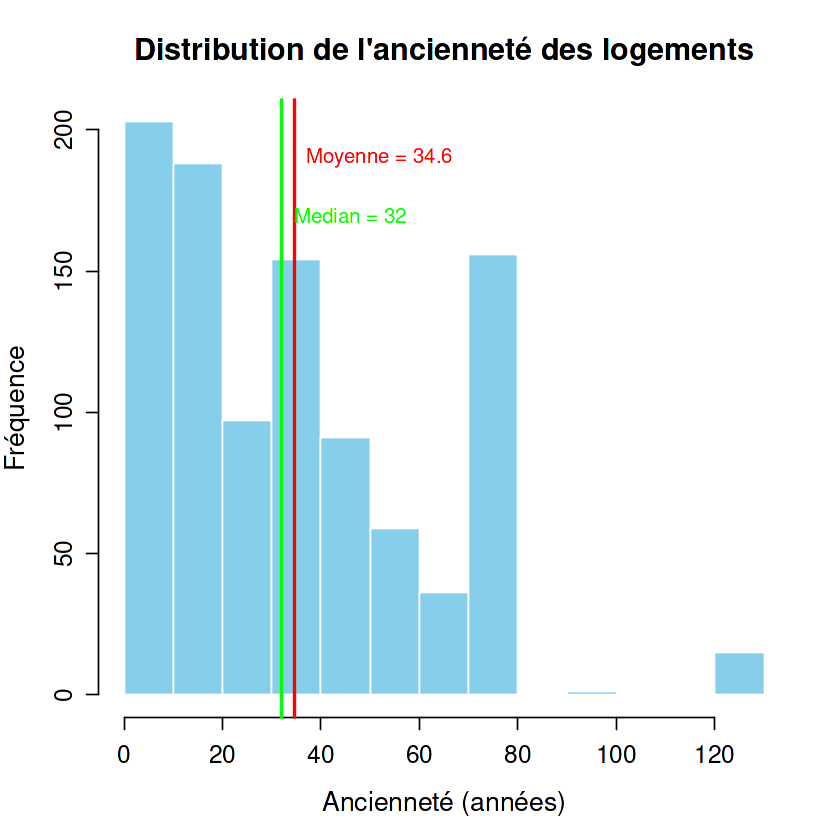

In [4]:
par(cex.main=1.5, cex.lab=1.3, cex.axis=1.2)

hist(data_dpe$anciennete,
     main ="Distribution de l'ancienneté des logements",
     xlab ="Ancienneté (années)",
     ylab ="Fréquence",
     col ="skyblue",border ="white")

# Calculer moyenne et median
moyenne <- mean(data_dpe$anciennete)
mediane <- median(data_dpe$anciennete)

# Ajouter une ligne pour la moyenne (rouge)
abline(v = moyenne, col ="red", lwd =2)
text(moyenne, par("usr")[4]*0.9,
     labels = paste0("Moyenne = ", round(moyenne,1)),col="red", pos=4)

# Ajouter une ligne pour la médiane (vert)
abline(v = mediane, col ="green", lwd =2)
text(mediane, par("usr")[4]*0.8,
     labels = paste0("Median = ", mediane),col="green", pos=4)

#### 2.1.2 Surface habitable

In [5]:
summary(data_dpe$surface_habitable)
sd(data_dpe$surface_habitable)
cv=round(sd(data_dpe$surface_habitable)/mean(data_dpe$surface_habitable)*100) 
cv

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  16.00   45.75   66.00   82.51   95.25 1452.00 

[1] 94.87407

[1] 115

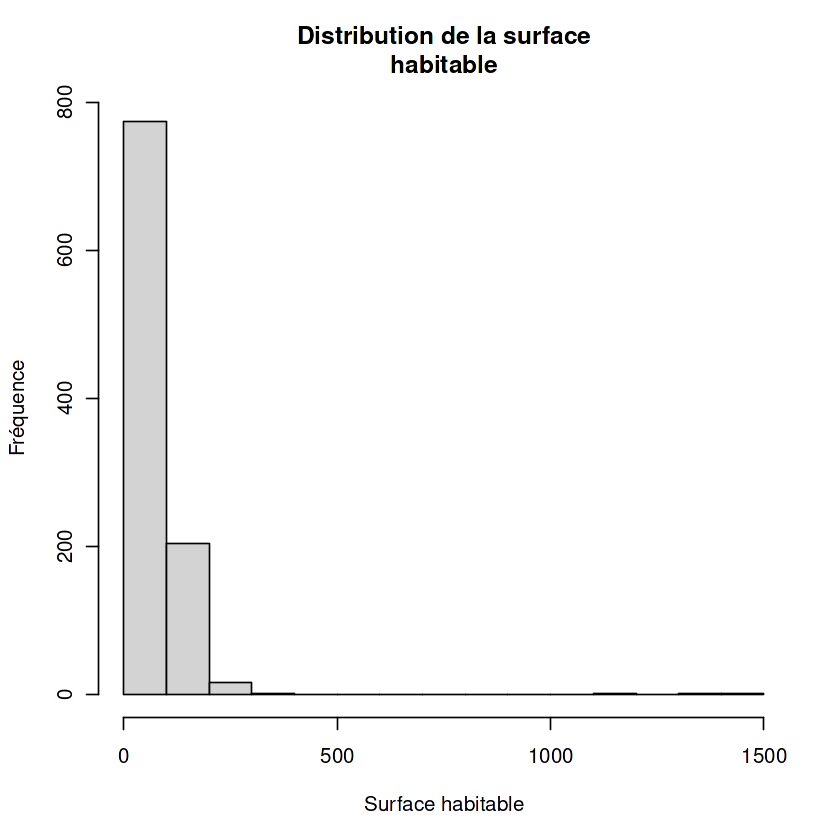

In [6]:
hist(data_dpe$surface_habitable, main = "Distribution de la surface
habitable", xlab = "Surface habitable",ylab = "Fréquence")

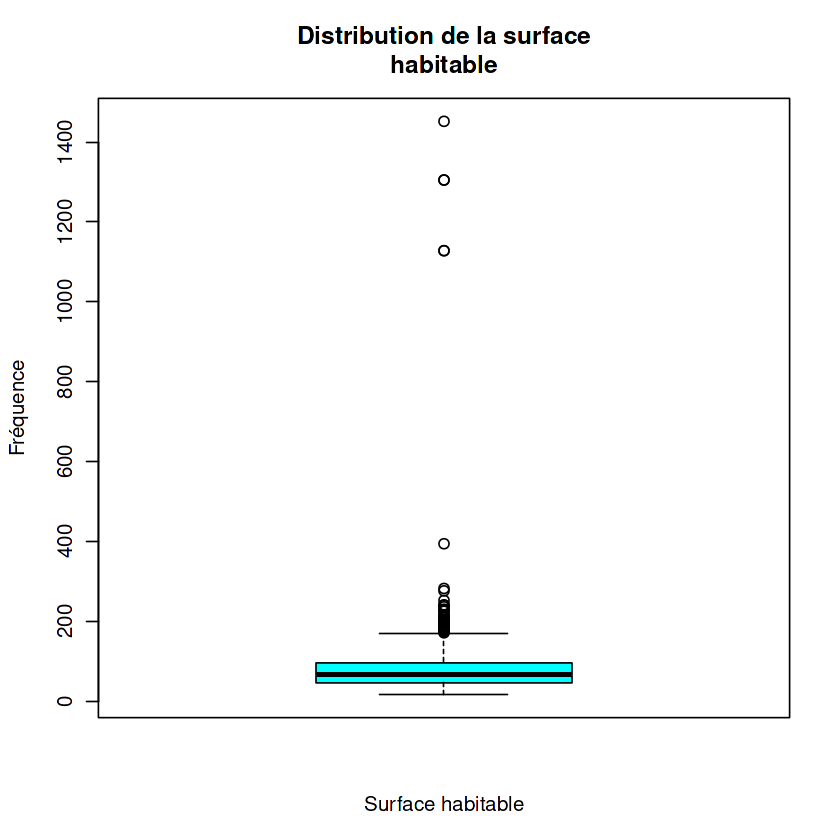

In [7]:
boxplot(data_dpe$surface_habitable, main = "Distribution de la surface
habitable", xlab = "Surface habitable",ylab = "Fréquence",col = "cyan")

#### 2.1.3 Consommation d’énergie

In [8]:
summary(data_dpe$conso_energie)
sd(data_dpe$conso_energie)
cv=round(sd(data_dpe$conso_energie)/mean(data_dpe$conso_energie))*100
cv

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  27.92  114.73  181.16  184.12  238.25  591.35 

[1] 96.89191

[1] 100

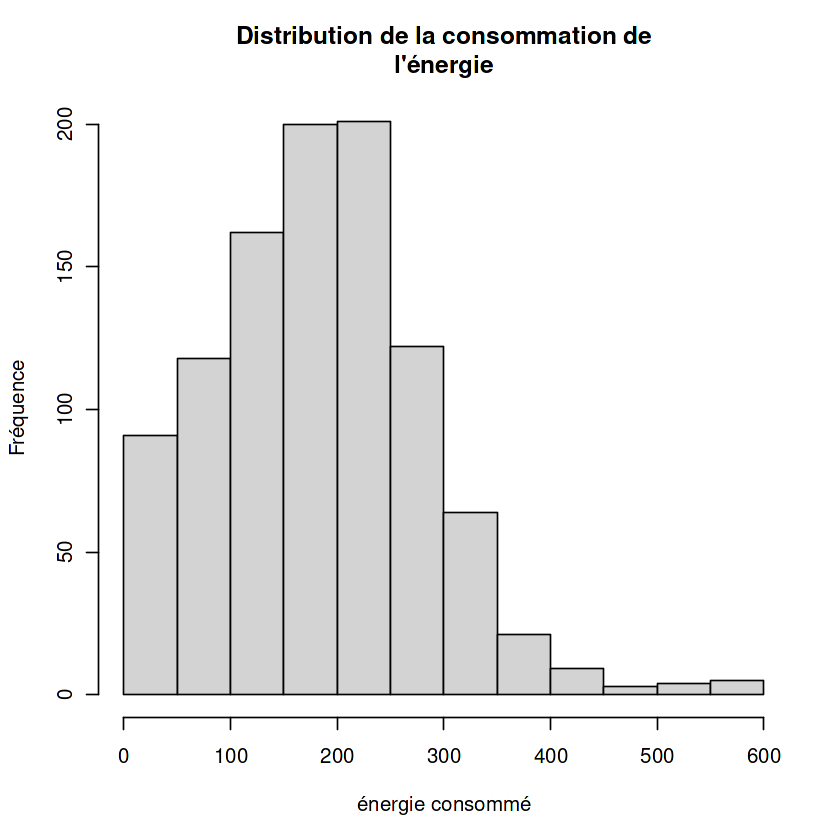

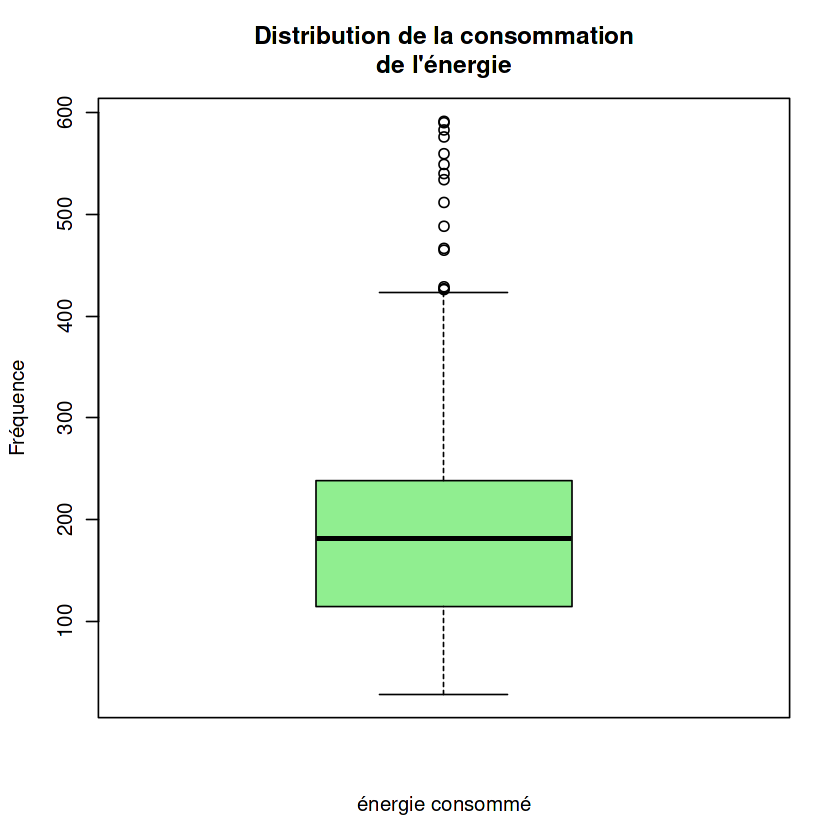

In [9]:
hist(data_dpe$conso_energie, main = "Distribution de la consommation de
l'énergie",xlab = "énergie consommé", ylab = "Fréquence")

boxplot(data_dpe$conso_energie, main = "Distribution de la consommation
de l'énergie", xlab = "énergie consommé", ylab = "Fréquence",col = "lightgreen")

#### 2.1.4 Émission de GES

In [10]:
summary(data_dpe$emission_ges)
sd(data_dpe$emission_ges)
cv=round(sd(data_dpe$emission_ges)/mean(data_dpe$emission_ges)*100)
cv

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.000   8.602  12.695  21.933  30.000 143.360 

[1] 20.64916

[1] 94

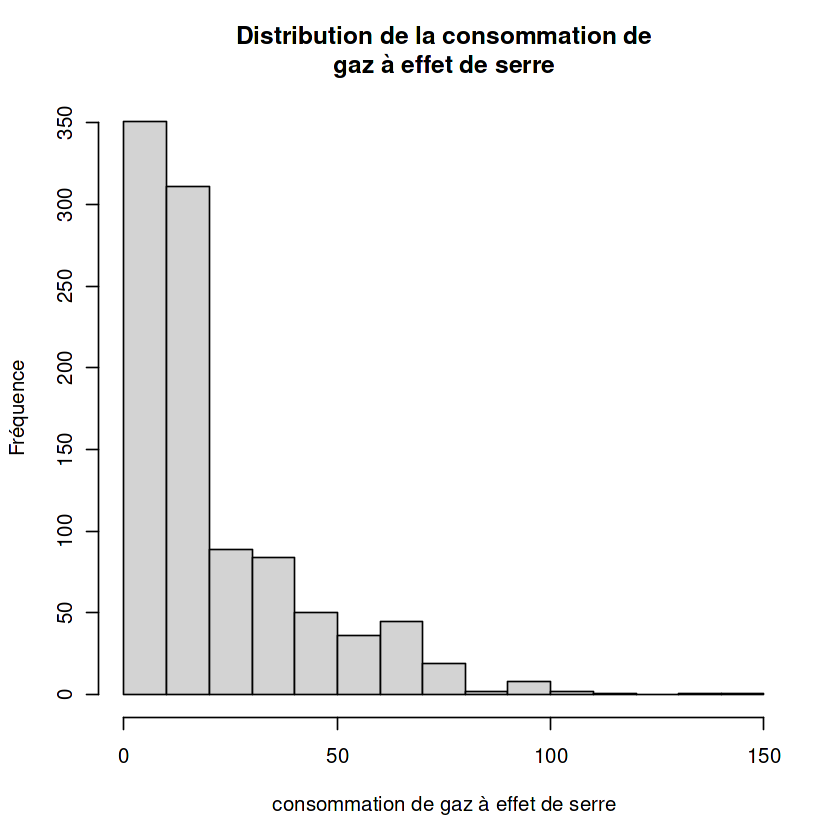

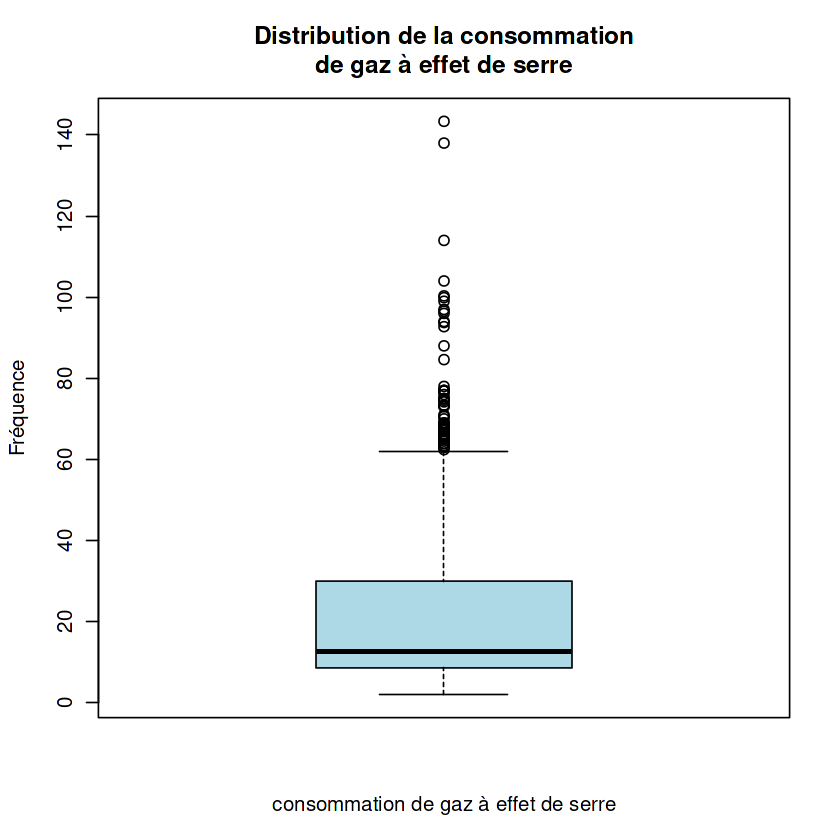

In [11]:
hist(data_dpe$emission_ges, main = "Distribution de la consommation de
gaz à effet de serre"
,xlab = "consommation de gaz à effet de serre",ylab = "Fréquence")

boxplot(data_dpe$emission_ges, main = "Distribution de la consommation
de gaz à effet de serre"
,xlab = "consommation de gaz à effet de serre"
,ylab = "Fréquence",col = "lightblue")

### 2.2 Variables qualitatives

#### 2.2.1 Le type de logement

In [12]:
data_dpe$type_logement <- factor(
  data_dpe$type_logement,levels = c(1, 2),labels = c("appartement", "maison"))
summary(data_dpe$type_logement)

appartement      maison 
        639         361

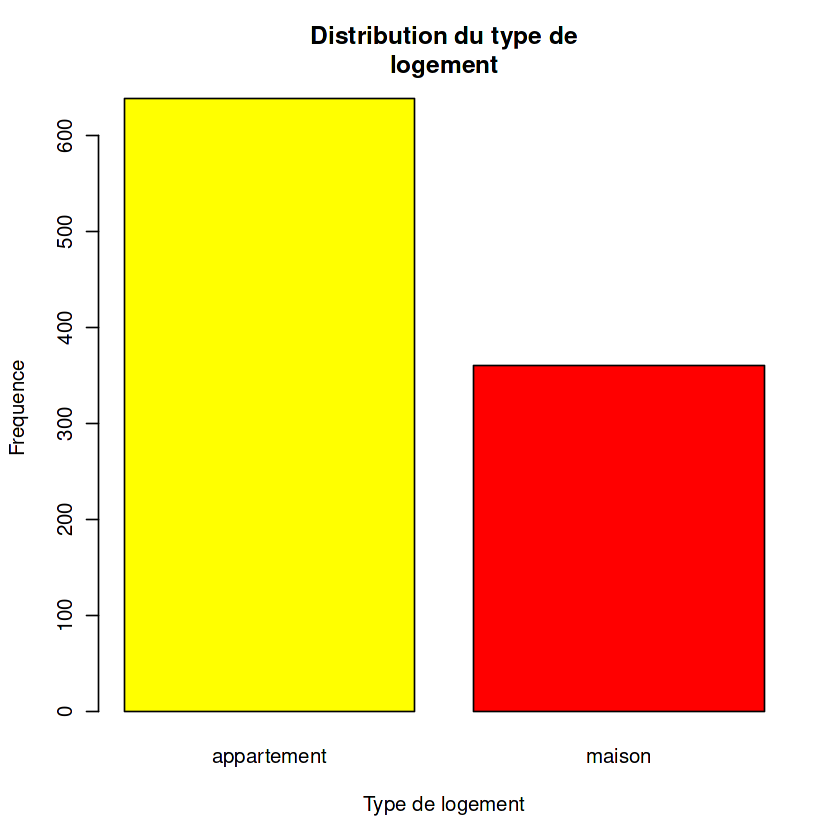

In [13]:
barplot(table(data_dpe$type_logement), main = "Distribution du type de
logement"
,xlab = "Type de logement",ylab= "Frequence",col = c("yellow","red"))

#### 2.2.2 Le type de l’energie chauffage

In [15]:
data_dpe$type_energie_chauffage <- factor(
  data_dpe$type_energie_chauffage,
  levels = c(1, 2, 3), labels = c("gaz", "électricité", "autre"))
summary(data_dpe$type_energie_chauffage)

gaz électricité       autre 
        433         542          25

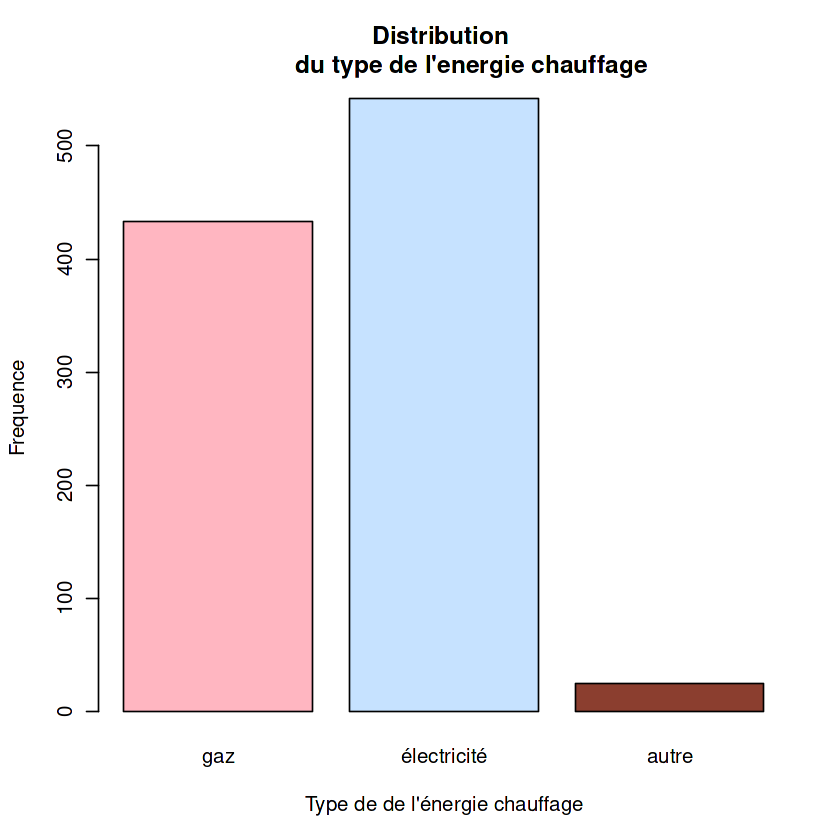

In [16]:
barplot(table(data_dpe$type_energie_chauffage), main = "Distribution 
        du type de l'energie chauffage"
        ,xlab = "Type de de l'énergie chauffage"
        ,ylab= "Frequence",col= c("lightpink","slategray1","coral4"))

#### 2.2.3 La classe de la consommation d’énergie

In [17]:
table(data_dpe$classe_conso_energie)


  A   B   C   D   E   F   G 
 98 295 274 121 127  70  15 

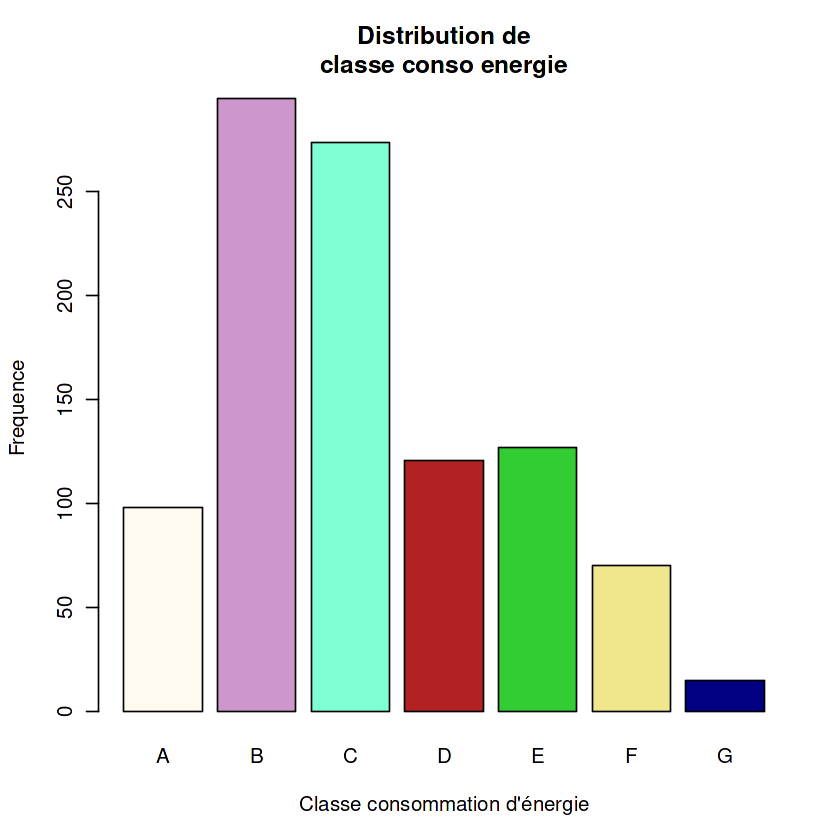

In [18]:
barplot(table(data_dpe$classe_conso_energie), main = "Distribution de
classe conso energie"
, xlab = "Classe consommation d'énergie"
, ylab= "Frequence"
,col =
c("floralwhite","plum3","aquamarine","firebrick","limegreen","khaki","navy"))

##  3. Analyse en composantes principales (ACP)

### 3.1 Dataset

In [21]:
housing <- data_dpe
data <- housing[, c("annee_construction","surface_habitable","conso_energie","emission_ges")]

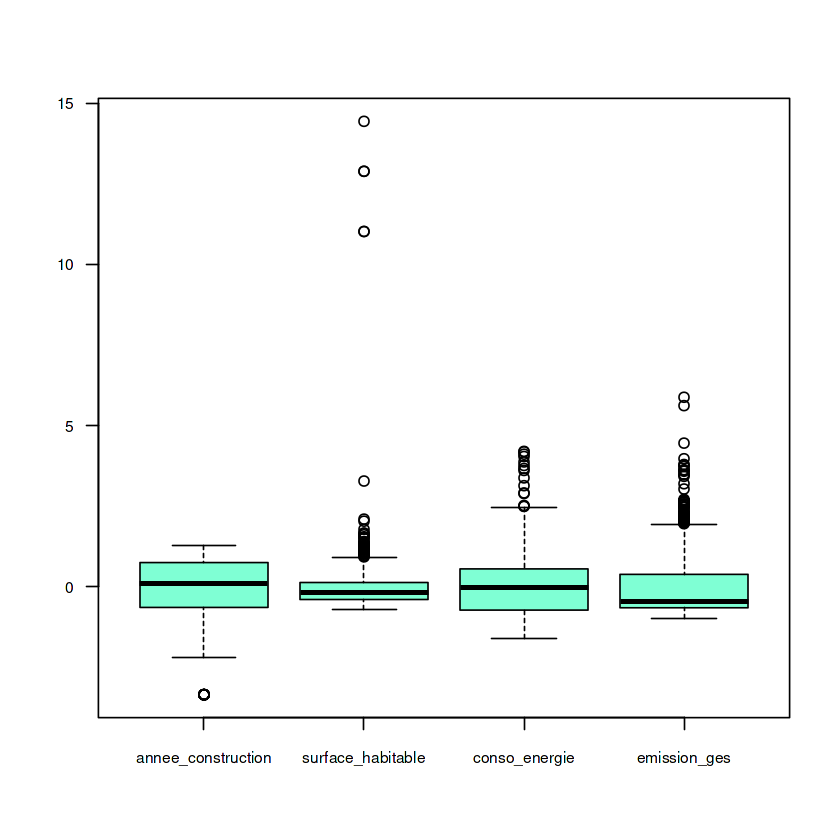

In [22]:
m<-colMeans(data)
s<-apply(data,MARGIN=2,FUN='sd')
I<-rep(1,nrow(data))
M<-I%*%t(m);
S<-I%*%t(s);
X<-(data-M)/S
boxplot(X,las=1,cex.axis = 0.75, col = "aquamarine")

### 3.2 Valeur propre et inertie

#### 3.2.1 La matrice des covariances

In [23]:
X<-as.matrix(X)# pour éviter les problèmes
V<-cor(X)
round(V,2)

,annee_construction,surface_habitable,conso_energie,emission_ges
annee_construction,1.00,-0.01,-0.49,-0.51
surface_habitable,-0.01,1.00,-0.13,0.02
conso_energie,-0.49,-0.13,1.00,0.44
emission_ges,-0.51,0.02,0.44,1.00


#### 3.2.2 Les valeurs propres

In [24]:
E<-eigen(V,symmetric=TRUE)
round(E$values,2)

[1] 1.96 1.02 0.54 0.47

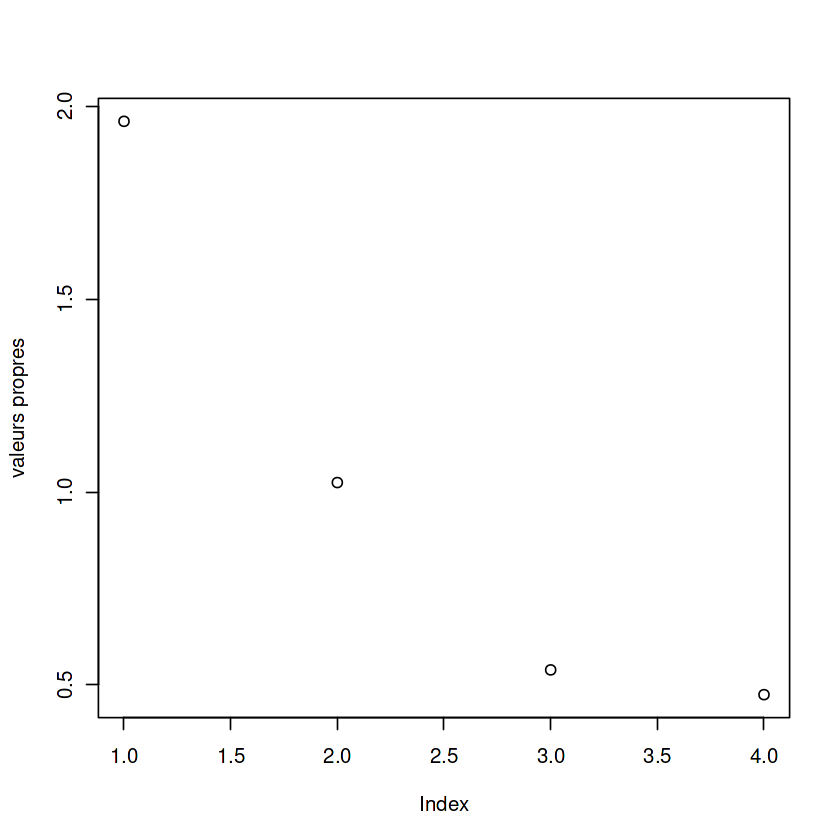

In [25]:
plot(E$values,ylab='valeurs propres')

In [26]:
cumsum(E$values)/ncol(X)

[1] 0.4903311 0.7465221 0.8812858 1.0000000

##### Méthode 1

In [27]:
# Matrice des vecteurs propres (eigenvectors) arrondie à 2 décimales
round(E$vectors,2)

# Coordonnées dans la nouvelle base
Y<-X%*%E$vectors

# calcul des corrélations avec la formule: 
k=2
D<-diag(sqrt(E$values))
C=E$vectors%*%D[,1:k]; 

# méthode directe: 
C2=cor(X,Y[,1:k])
C2-C # vérification 

0.59,-0.12,0.06,0.80
0.06,0.97,-0.21,0.11
-0.57,-0.16,-0.67,0.45
-0.57,0.15,0.71,0.39


annee_construction,-2.220446e-16,1.249001e-16
surface_habitable,8.326673e-17,1.554312e-15
conso_energie,2.220446e-16,-1.110223e-16
emission_ges,2.220446e-16,2.220446e-16


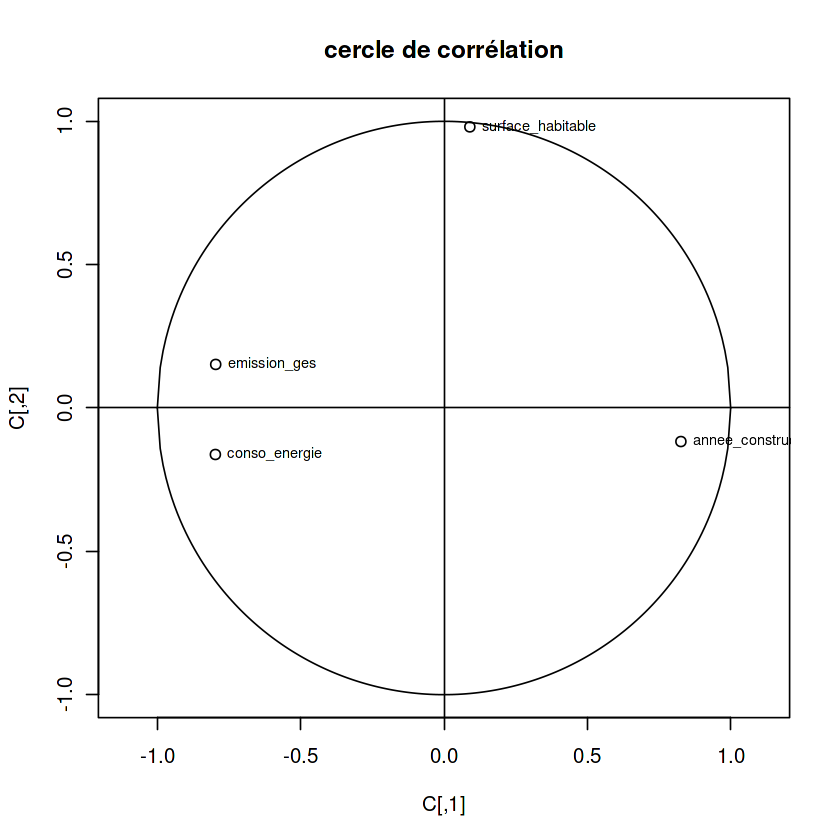

In [28]:
plot(C,main='cercle de corrélation',ylim=c(-1,1),xlim=c(-1,1),asp = 1  )
text(C,labels=colnames(X),pos=4,cex=0.7) # ajout des labels aux points
# on ajoute le cercle et les deux axes
x<-seq(-1,1,0.01)
lines(x,sqrt(1-x^2))
lines(x,-sqrt(1-x^2))
abline(h=0)
abline(v=0)

##### Méthode 2: On fait avec les packages FactoMineR,factoextra

In [30]:
library(FactoMineR)
library(factoextra)

Loading required package: ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



In [32]:
acp <- PCA(X, scale.unit = T)

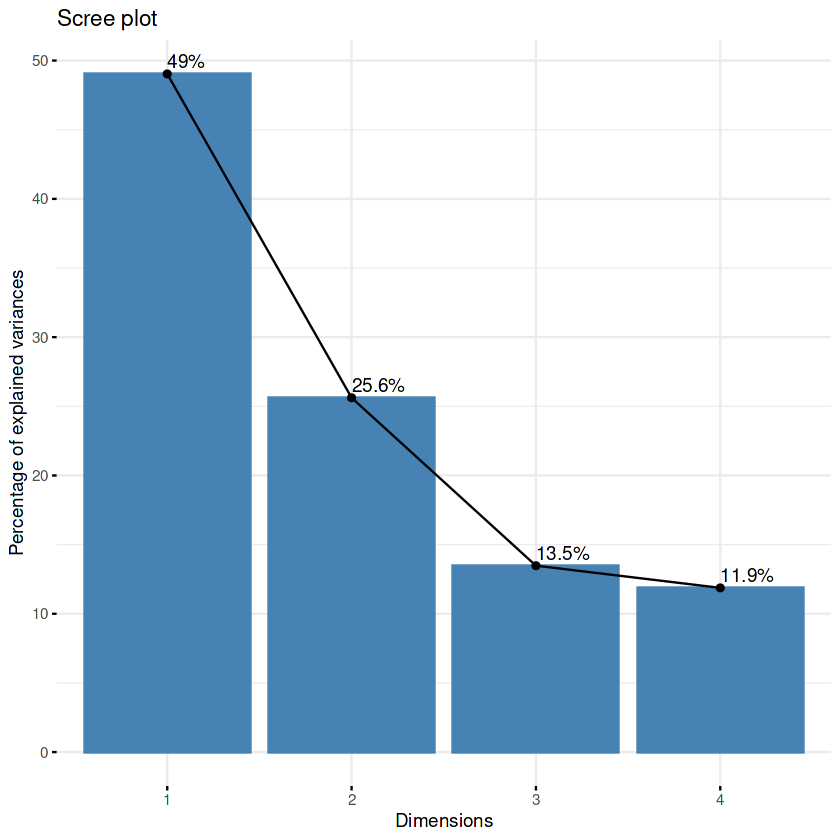

In [33]:
fviz_eig(acp,addlabels = T)

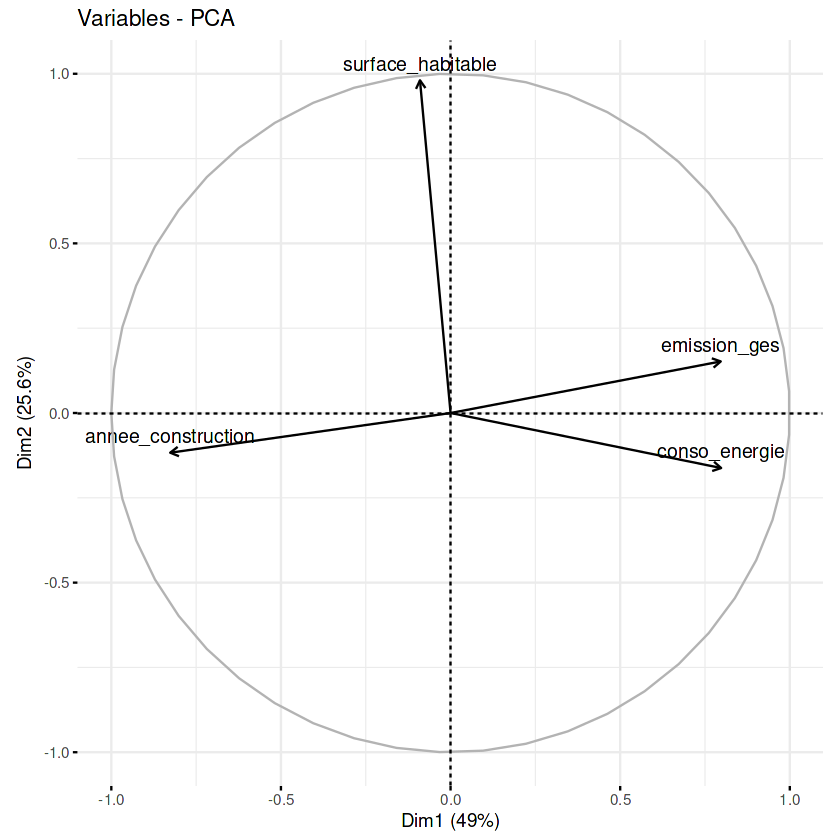

In [34]:
fviz_pca_var(acp, axes = c(1,2), select.var = list(cos2 = 0.1)) 

#####  Relations entre les variables (Corrélations)

La distance et l’angle entre les points (variables) indiquent leur niveau de corrélation :

- **Corrélation positive** : *emission_ges* (émissions de gaz à effet de serre) et *conso_energie* (consommation d’énergie) sont très proches l’une de l’autre. Cela signifie qu’elles sont positivement corrélées : les logements qui consomment beaucoup d’énergie ont généralement des émissions élevées.

- **Corrélation négative** : *annee_construction* (année de construction) est situé à l’opposé du groupe énergie/émissions par rapport au centre du cercle (selon l’axe horizontal). Cela suggère que les bâtiments plus anciens (année de construction plus faible) ont tendance à consommer davantage d’énergie et à émettre plus de gaz à effet de serre.

- **Indépendance (absence de corrélation)** : *surface_habitable* (surface habitable) est proche de l’axe vertical, formant un angle proche de 90° avec les autres variables. Cela signifie que, dans cet ensemble de données, la surface du logement est peu liée à l’année de construction ou à la performance énergétique par unité de surface.

##  4. Analyse des correspondances multiples (ACM)

In [52]:
maison <- data_dpe
data1 <- maison[, c("type_logement","type_energie_chauffage","classe_conso_energie")]
summary(data1)

     type_logement type_energie_chauffage classe_conso_energie
 appartement:639   gaz        :433        Length:1000         
 maison     :361   électricité:542        Class :character    
                   autre      : 25        Mode  :character    

In [64]:
data1 <- data_dpe[, c("type_logement", 
                      "type_energie_chauffage", 
                      "classe_conso_energie")]
str(data1)
data1$type_logement <- trimws(tolower(data1$type_logement))
data1$type_energie_chauffage <- trimws(tolower(data1$type_energie_chauffage))
data1$classe_conso_energie <- trimws(toupper(data1$classe_conso_energie))

data1$type_logement <- factor(
  data1$type_logement,
  levels = c("appartement", "maison"),
  labels = c("Appartement", "Maison")
)

data1$type_energie_chauffage <- factor(data1$type_energie_chauffage)
data1$classe_conso_energie <- factor(
  data1$classe_conso_energie,
  levels = c("A", "B", "C", "D", "E", "F", "G"),
  ordered = TRUE
)

summary(data1)

'data.frame':	1000 obs. of  3 variables:
 $ type_logement         : Factor w/ 2 levels "appartement",..: 1 1 1 2 1 2 2 1 1 1 ...
 $ type_energie_chauffage: Factor w/ 3 levels "gaz","électricité",..: 2 1 2 1 1 2 1 2 1 2 ...
 $ classe_conso_energie  : chr  "C" "D" "C" "F" ...


     type_logement type_energie_chauffage classe_conso_energie
 Appartement:639   autre      : 25        A: 98               
 Maison     :361   électricité:542        B:295               
                   gaz        :433        C:274               
                                          D:121               
                                          E:127               
                                          F: 70               
                                          G: 15               

In [65]:
data1.mca <- MCA(data1, graph = FALSE)
data1.mca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.5654050,18.846832,18.84683
dim 2,0.4397829,14.659430,33.50626
dim 3,0.3651877,12.172924,45.67919
dim 4,0.3333333,11.111111,56.79030
dim 5,0.3333333,11.111111,67.90141
dim 6,0.3333333,11.111111,79.01252
dim 7,0.2714109,9.047031,88.05955
dim 8,0.2470885,8.236284,96.29583
dim 9,0.1111250,3.704166,100.00000


In [ ]:
fviz_mca_var(data1.mca,repel=TRUE,geom.var=c('arrow','text'))

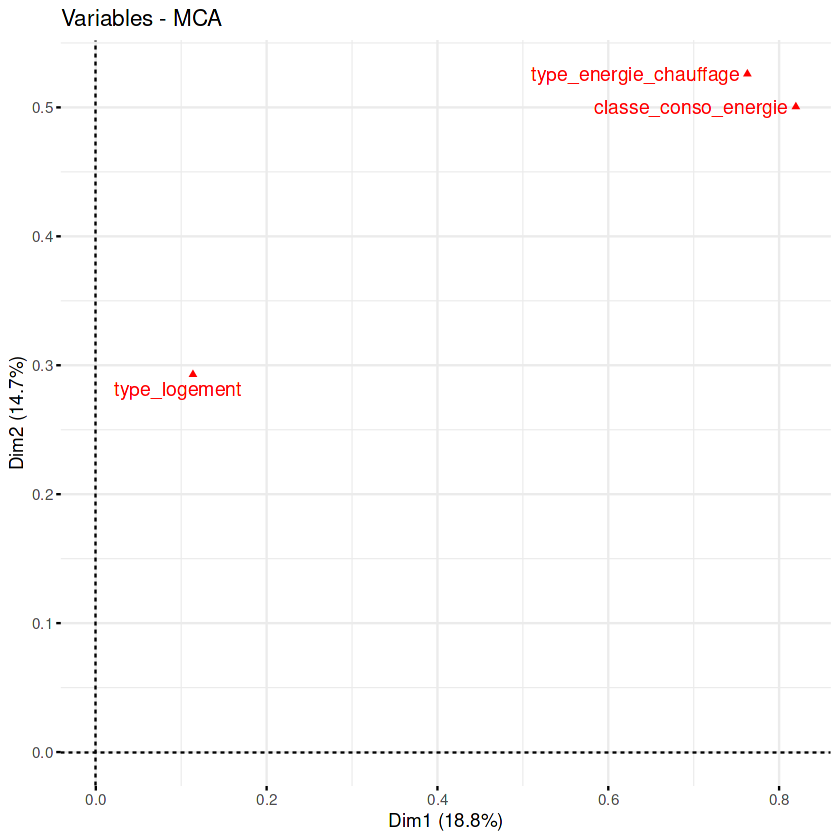

In [67]:
fviz_mca_var(data1.mca,choice='var',repel=TRUE)

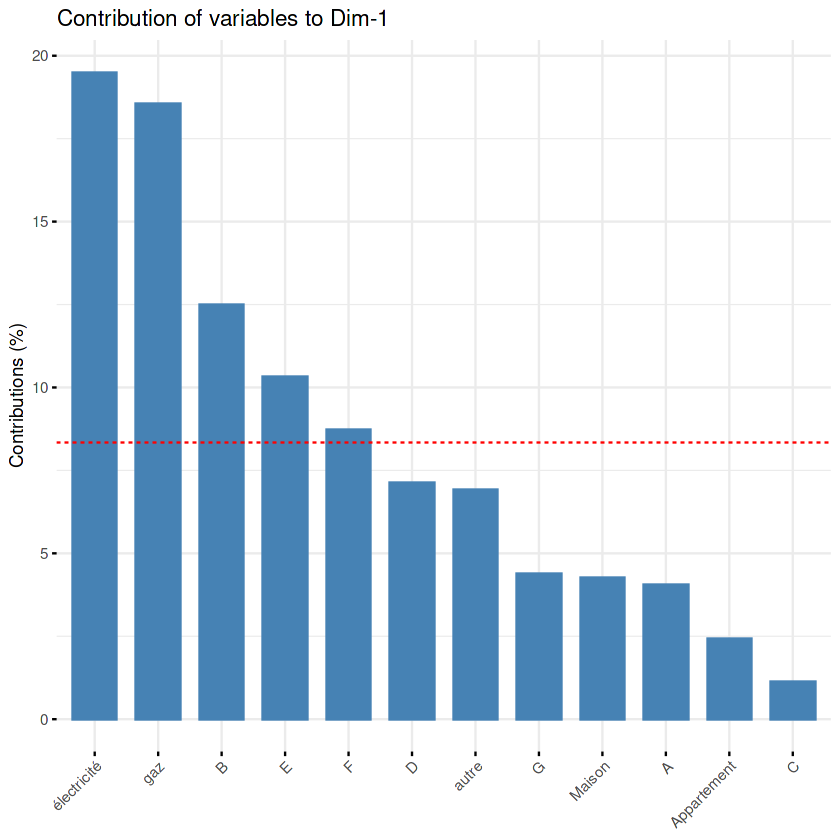

In [68]:
fviz_contrib(data1.mca,choice='var')

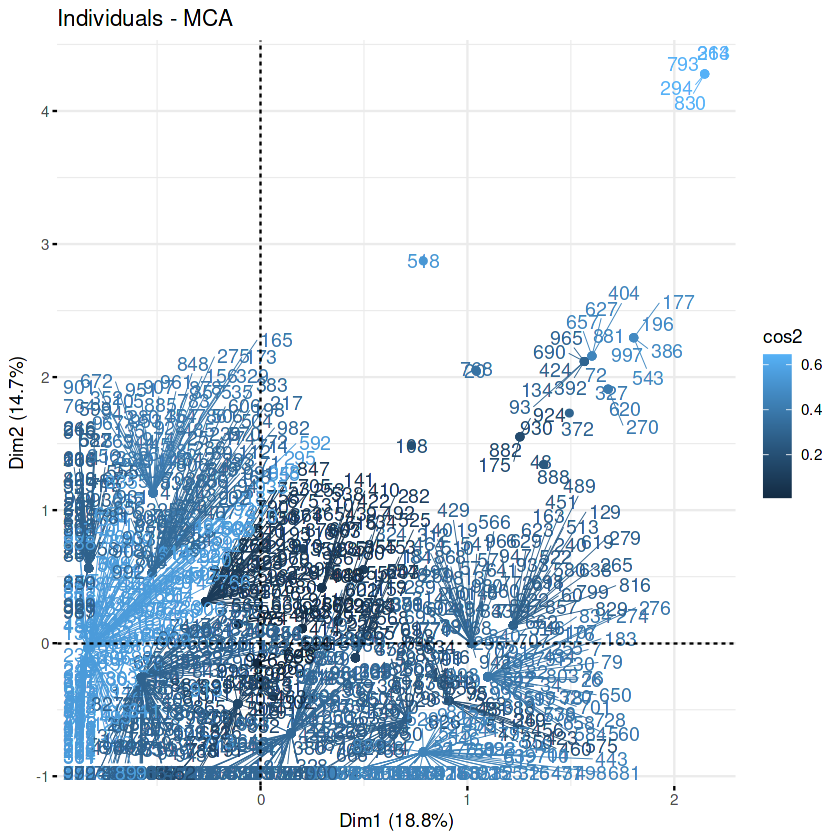

In [69]:
fviz_mca_ind(data1.mca,col.ind = "cos2", repel = TRUE)

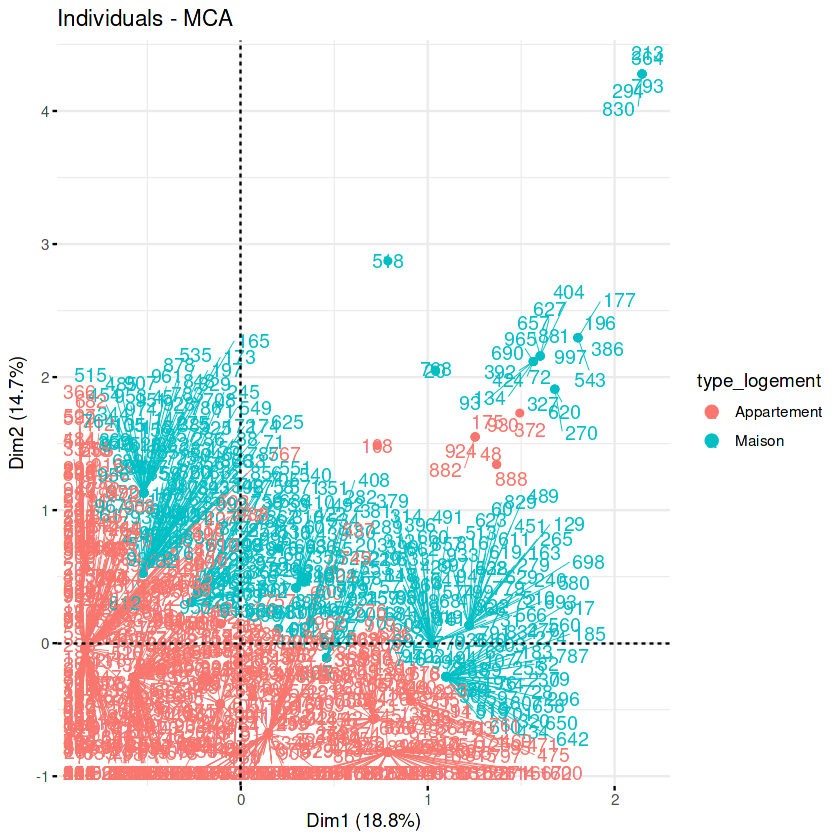

In [71]:
fviz_mca_ind(data1.mca,habillage="type_logement", repel = TRUE)

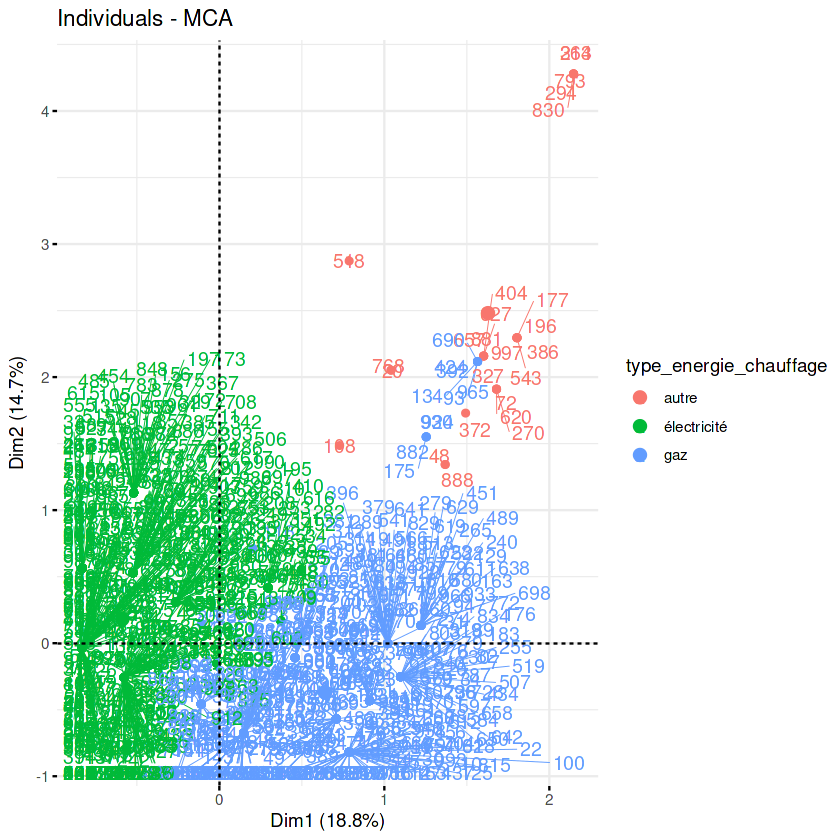

In [72]:
fviz_mca_ind(data1.mca,habillage="type_energie_chauffage",repel=TRUE)

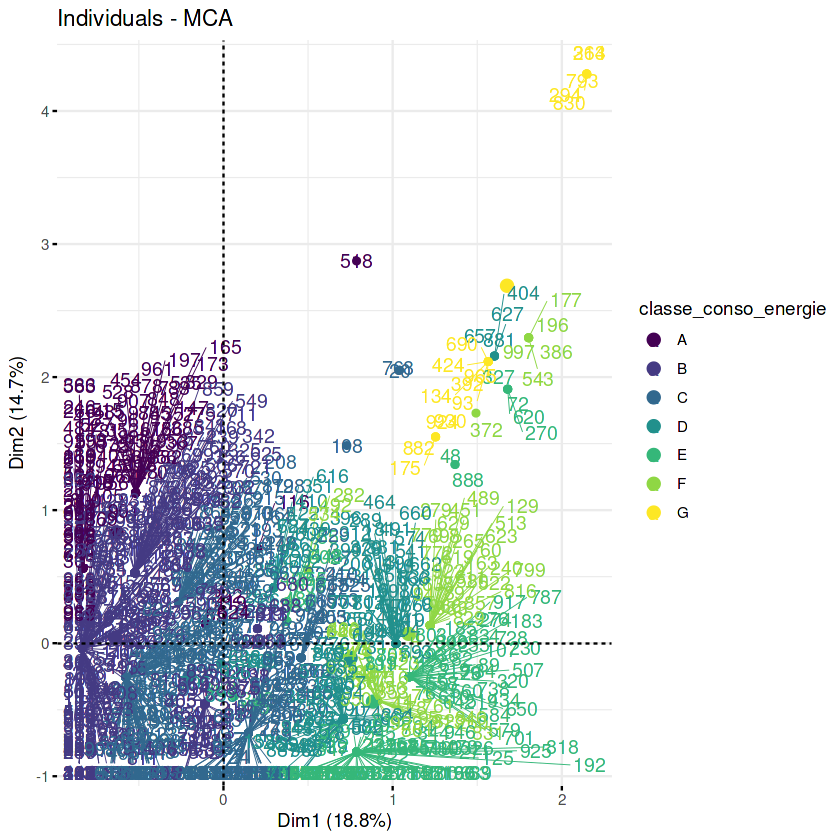

In [73]:
fviz_mca_ind(data1.mca,habillage="classe_conso_energie",repel=TRUE)

## 5 Test

### 5.1 Test Chi Deux

On va faire le test pour savoir si la classe de consommation dépend-elle du type de chauffage

Hypothèse:

-H0: La classe de consommation indépendante du type de chauffage.

-H1: La classe de consommation dépend du type de chauffage.


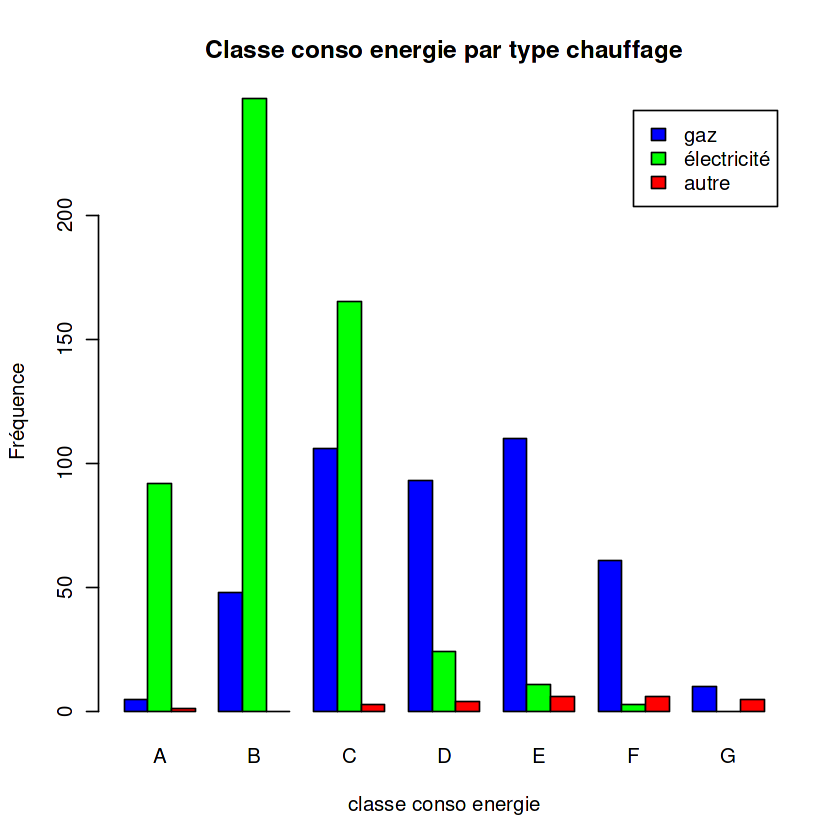

In [74]:
type_energie_chauffage <-data_dpe$type_energie_chauffage
classe_conso_energie <- data_dpe$classe_conso_energie
barplot(table(type_energie_chauffage,classe_conso_energie),beside=TRUE,
        col=c("blue","green","red"), main="Classe conso energie par type chauffage"
        ,xlab= "classe conso energie"
        ,ylab="Fréquence ",legend.text=TRUE)

In [75]:
table_conso_energie <- table (data_dpe$type_energie_chauffage,
                                   data_dpe$classe_conso_energie)
table_conso_energie

chisq.test(table_conso_energie)

             
                A   B   C   D   E   F   G
  gaz           5  48 106  93 110  61  10
  électricité  92 247 165  24  11   3   0
  autre         1   0   3   4   6   6   5

Warning message in chisq.test(table_conso_energie):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  table_conso_energie
X-squared = 477.22, df = 12, p-value < 2.2e-16


### 5.2 Test ANOVA

#### 5.2.1 Tester s'il y a une différence réelle de consommation énergétique moyenne entre Maison et Appartement.

On va faire le test pour savoir justifier la relation entre le type de logement et la consommation d'énergie

 - H0: Il n’y a pas de différence moyenne de consommation énergétique entre Maison et Appartement (toute variation observée est due au hasard)

 - H1: Il existe une différence réelle de consommation énergétique moyenne entre Maison et Appartement.

In [76]:
anova_result <- aov(conso_energie ~ type_logement, data = maison)

summary(anova_result)

               Df  Sum Sq Mean Sq F value   Pr(>F)    
type_logement   1  103182  103182    11.1 0.000894 ***
Residuals     998 9275471    9294                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [77]:
aggregate(conso_energie ~ type_logement, data = maison, mean)

type_logement,conso_energie
<fct>,<dbl>
appartement,176.4841
maison,197.6335


#### 5.2.2 Tester si les moyennes des émissions de GES sont identiques selon le type d’énergie de chauffage.


On va faire le test pour savoir justifier les moyennes des émissions de GES sont identiques selon le type d’énergie de chauffage.

- H0: Les groupes ont des moyennes d’émissions égales.

- H1: Au moins un groupe a une moyenne différente.


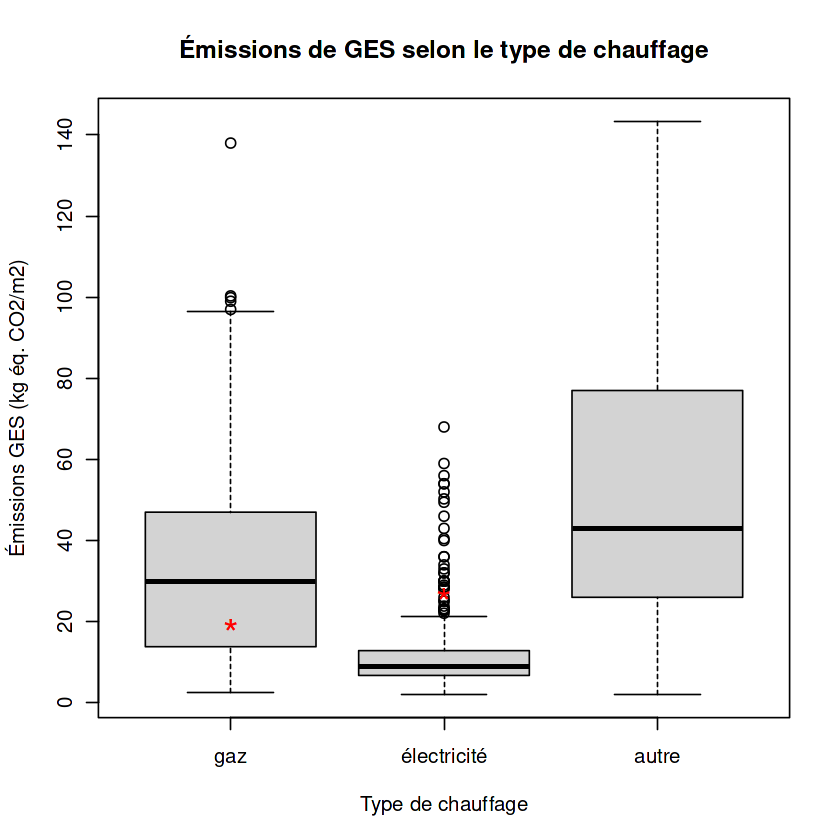

In [78]:
moycond <- tapply(data_dpe$emission_ges, data_dpe$type_logement, mean, na.rm=TRUE)
boxplot(emission_ges ~ type_energie_chauffage,
data = data_dpe,
main = "Émissions de GES selon le type de chauffage",
xlab = "Type de chauffage",
ylab = "Émissions GES (kg éq. CO2/m2)")
# ajouter le point de moyen
points(1:length(moycond), moycond, col="red", pch="*", cex=2)

In [79]:
oneway.test(emission_ges~ type_energie_chauffage, data=data_dpe, var.equal=FALSE)


	One-way analysis of means (not assuming equal variances)

data:  emission_ges and type_energie_chauffage
F = 219.53, num df = 2.000, denom df = 61.494, p-value < 2.2e-16


### 5.3 Tests t de Student par paires

On va vérifier si les moyennes des émissions de GES diffèrent selon le type d’énergie de chauffage.

- H0: Les groupes ont des moyennes d’émissions égales.

- H1: Au moins un groupe a une moyenne différente.

In [80]:
pairwise.t.test(data_dpe$emission_ges,data_dpe$type_energie_chauffage,
                p.adjust.method = "none",pool.sd = FALSE)


	Pairwise comparisons using t tests with non-pooled SD 

data:  data_dpe$emission_ges and data_dpe$type_energie_chauffage 

            gaz     électricité
électricité < 2e-16 -          
autre       0.0053  1.8e-06    

P value adjustment method: none 

**Comparaison par paires des groupes d’énergie** :

- Gaz vs Électricité → p < 2e-16 → différence extrêmement significative

- Gaz vs Autre → p = 0,0053 → différence significative

- Électricité vs Autre → p = 1,8e-06 → différence extrêmement significative

Conclusion : toutes les paires de groupes d’énergie présentent des différences significatives au niveau
des émissions.